# Curated 

**Rigorous QA**

What get's done:
- Valid mask: Only pixels where both bands > 0 are processed
- Cloud mask validation / refinement
- Atmospheric correction QA
- Co-registration checks
- Outlier removal
- Edge artifacts handling

Sentinel-2 L2A bands are scaled surface reflectanc (x10000) store as integers, not raw DN


In [329]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.ndimage import binary_dilation, binary_erosion, binary_opening, label
import rasterio
from rasterio.mask import mask
import warnings
import geopandas as gpd

In [298]:
# ─── 1. Directorios ────────────────────────────────────────
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR = os.path.join(BASE_DIR, 'data')
OUTPUT_DIR = os.path.join(BASE_DIR, r'output\with_qa')
os.makedirs(OUTPUT_DIR, exist_ok=True)

DATA_PREFIRE_DIR = os.path.join(DATA_DIR, 'prefire')
DATA_POSTFIRE_DIR = os.path.join(DATA_DIR, 'postfire')
OUT_PREFIRE_DIR = os.path.join(OUTPUT_DIR, 'prefire')
OUT_POSTFIRE_DIR = os.path.join(OUTPUT_DIR, 'postfire')

AOI_PATH = os.path.join(DATA_DIR, 'aoi.geojson')

# ─── 2. Rutas corregidas (ejemplo 2025-08-01 y 2025-08-23) ───

clip_pre = {
    'B04': os.path.join(DATA_PREFIRE_DIR, 'clip_red.tiff'),
    'B8A': os.path.join(DATA_PREFIRE_DIR, 'clip_nir.tiff'),
    'B12': os.path.join(DATA_PREFIRE_DIR, 'clip_swir2.tiff'),
    'SCL': os.path.join(DATA_PREFIRE_DIR, 'clip_scl.tiff'),
    'AOT': os.path.join(DATA_PREFIRE_DIR, 'clip_aot.tiff'),
    'WVP': os.path.join(DATA_PREFIRE_DIR, 'clip_wvp.tiff')
}

clip_post = {
    'B04': os.path.join(DATA_POSTFIRE_DIR, 'clip_red.tiff'),
    'B8A': os.path.join(DATA_POSTFIRE_DIR, 'clip_nir.tiff'),
    'B12': os.path.join(DATA_POSTFIRE_DIR, 'clip_swir2.tiff'),
    'SCL': os.path.join(DATA_POSTFIRE_DIR, 'clip_scl.tiff'),
    'AOT': os.path.join(DATA_POSTFIRE_DIR, 'clip_aot.tiff'),
    'WVP': os.path.join(DATA_POSTFIRE_DIR, 'clip_wvo.tiff')
}

# 3. Masks

CLOUD_PRE = os.path.join(OUT_PREFIRE_DIR, 'cloud_pre.tif')
CLOUD_POST = os.path.join(OUT_POSTFIRE_DIR, 'cloud_post.tif')

SMOKE_PRE = os.path.join(OUT_PREFIRE_DIR, 'smoke_pre.tif')
SMOKE_POST = os.path.join(OUT_POSTFIRE_DIR, 'smoke_post.tif')

SAT_PRE = os.path.join(OUT_PREFIRE_DIR, 'saturation_pre.tif')
SAT_POST = os.path.join(OUT_POSTFIRE_DIR, 'saturation_post.tif')

OUTLIER_PRE = os.path.join(OUT_PREFIRE_DIR, 'outlier_pre.tif')
OUTLIER_POST = os.path.join(OUT_POSTFIRE_DIR, 'outlier_post.tif')

EDGE_PRE = os.path.join(OUT_PREFIRE_DIR, 'edge_pre.tif')
EDGE_POST = os.path.join(OUT_POSTFIRE_DIR, 'edge_post.tif')

OUT_PRE  = os.path.join(OUT_PREFIRE_DIR, 'nir_swir2_clip_prefire_raw.tif')
OUT_POST = os.path.join(OUT_POSTFIRE_DIR, 'nir_swir2_clip_postfire_raw.tif')

NBR_PRE  = os.path.join(OUT_PREFIRE_DIR, 'nbr_pre.tif')
NBR_POST = os.path.join(OUT_POSTFIRE_DIR, 'nbr_post.tif')


## Masks and atmospheric validation

In [299]:
def cloud_mask(scl_path, out_path):
        """
        Sensor QA:
        Enhanced cloud mask using all clouds
        """
        # SCL values:
        # 8 = Cloud medium probability
        # 9 = Cloud high probability
        # 10 = Thin cirrus
        # 3 = Cloud shadows

        with rasterio.open(scl_path) as src:
                scl = src.read(1)
                meta = src.meta.copy()
         
        # Start with SCL clouds (more conservative )
        cloud_mask = np.isin(scl, [3, 8, 9, 10]).astype(np.uint8)  # # Shadows, medium/high prob, cirrus

        # Buffer clouds (clouds cast shadows, edges uncertain)
        cloud_mask = binary_dilation(cloud_mask, iterations=3)
        
        cloud_fraction = np.sum(cloud_mask) / cloud_mask.size
        print(f"  Cloud fraction: {cloud_fraction:.1%}")

        meta.update({
        "driver": "GTiff",
        "count": 1,
        "dtype": "float32",
        "nodata": -9999.0 #masked/cloud
        })

        with rasterio.open(out_path, "w", **meta) as dst:
                dst.write(cloud_mask, 1)
        
        return cloud_mask

In [300]:
cloud_pre = cloud_mask(
    clip_pre['SCL'], 
    CLOUD_PRE
)

cloud_post = cloud_mask(
    clip_post['SCL'], 
    CLOUD_POST
)

  Cloud fraction: 0.0%
  Cloud fraction: 0.0%


In [391]:
def smoke_mask(b8a_path, b12_path, slc_path, out_path):
        """
        Sensor QA
        Detect smoke (different spectral signature than clouds)
        Critical for post-fire imagery!

        Smoke characteristics:
        - Lower reflectance than clouds in visible
        - Higher reflectance than vegetation in NIR
        - Different texture than clouds
        """
        # Smoke typically has:
        # - Moderate blue reflectance (not as bright as clouds)
        # - Reduced NIR absortion
        # - May be flagged as thin cirrus by SCL
        
        with rasterio.open(b8a_path) as src:
                b8a = src.read(1).astype("float32") / 10000.0
                meta = src.meta.copy()
        
        with rasterio.open(b12_path) as src:
                b12 = src.read(1).astype("float32") / 10000.0

        with rasterio.open(slc_path) as src:
                scl = src.read(1).astype(np.float32)
             
        # Simple smoke index
        smoke_candidate = (
                (b8a > 0.15) &        # must still be bright enough
                (b8a < 0.35) &        # not clouds
                (b12 < 0.2) &         # smoke has low SWIR
                ((b8a - b12) > 0.02)  # weak vegetation-like contrast
        )

        # Cross-chech with SCL thin cirrus (often smoke)
        scl_smoke = (scl == 10)

        smoke_mask = smoke_candidate & scl_smoke

        # Morphological cleaning
        smoke_mask = binary_opening(smoke_mask, iterations=1)

        # Smoke fraction
        smoke_fraction = np.sum(smoke_mask) / smoke_mask.size
        print(f"  Smoke fraction: {smoke_fraction:.1%}")

        meta.update({
        "driver": "GTiff",
        "count": 1,
        "dtype": "float32",
        "nodata": -9999 #masked/smoke
        })

        with rasterio.open(out_path, "w", **meta) as dst:
                dst.write(smoke_mask, 1)

        return smoke_mask

In [392]:
smoke_pre = smoke_mask(
    clip_pre['B8A'],
    clip_pre['B12'],
    clip_pre['SCL'], 
    SMOKE_PRE
)

smoke_post = smoke_mask(
    clip_post['B8A'],
    clip_post['B12'],
    clip_post['SCL'], 
    SMOKE_POST
)

  Smoke fraction: 0.0%
  Smoke fraction: 0.0%


In [303]:
def validate_atmospheric_correction(aot_path, wvp_path, b12_path):
    """
    Validate atmospheric correction quality (Sentinel-2 L2A)

    This is NOT QA masking
    It is diagnostic sanity check for:
    - Aerosol loading
    - Water vapor anomalies
    - Overcorrection artifacts

    Returns:
        issues (int): number of detected concerns
    """
    issues = 0

    with rasterio.open(aot_path) as src:
        aot = src.read(1).astype("float32") / 1000.0
    
    if np.any(aot < 0):
        warnings.warn("Negative AOT values detected")
        issues += 1
    
    mean_aot = np.nanmean(aot)

    # Check AOT (Aerosol Optical Thickness)
    if mean_aot is not None:
        if mean_aot > 0.4:
            warnings.warn(f"High aerosol loading (AOT = {mean_aot: .2f})")
            issues += 1
        
    with rasterio.open(wvp_path) as src:
        wvp = src.read(1).astype("float32") / 10000.0

    mean_wvp = np.nanmean(wvp)

    # Check Water Vapor
    if wvp is not None:
        if mean_wvp > 6.0 or mean_wvp < 0:
            warnings.warn(f"Unusual water vapor values (WVP = {mean_wvp: .2f})")
            issues += 1

    # Negative reflectance check (overcorrection)
    with rasterio.open(b12_path) as src:
        b12 = src.read(1).astype("float32") / 10000.0
    
    if np.any(b12 < -0.01):
        warnings.warn("Negative reflectance detected - atmospheric overcorrection")

    return issues
    

In [304]:
aot_pre = validate_atmospheric_correction(
    clip_pre['AOT'],
    clip_pre['WVP'],
    clip_pre['B12']
)

aot_post = validate_atmospheric_correction(
    clip_post['AOT'],
    clip_post['WVP'],
    clip_post['B12']
)

C:\Users\User\AppData\Local\Temp\ipykernel_46040\3958656459.py:20: UserWarning: Negative AOT values detected
  warnings.warn("Negative AOT values detected")
C:\Users\User\AppData\Local\Temp\ipykernel_46040\3958656459.py:47: UserWarning: Negative reflectance detected - atmospheric overcorrection
  warnings.warn("Negative reflectance detected - atmospheric overcorrection")


In [305]:
def saturation_mask(b8a_path, b12_path, out_path, threshold):
    """
    Radiometric QA:
    Check for saturation pixels
    A pixel is saturated if any band exceeds the threshold
    """
    with rasterio.open(b8a_path) as src:
        b8a = src.read(1).astype("float32") / 10000.0 # rescale reflectance before thresholding
        meta = src.meta.copy()
     
    with rasterio.open(b12_path) as src:
        b12 = src.read(1).astype("float32") / 10000.0 # rescale reflectance before thresholding

    sat_mask = (b8a > threshold) | (b12 > threshold)

    # Saturation fraction
    sat_fraction = np.sum(sat_mask) / sat_mask.size
    print(f"  Saturation fraction: {sat_fraction:.1%}")

    #Prepare output array
    sat_mask_out = sat_mask.astype(np.uint8)

    meta.update({
    "driver": "GTiff",
    "count": 1,
    "dtype": "float32",
    "nodata": -9999.0 #masked/saturated
    })

    with rasterio.open(out_path, "w", **meta) as dst:
        dst.write(sat_mask_out, 1)

    return sat_mask

In [306]:
sat_pre = saturation_mask(
    clip_pre['B8A'],
    clip_pre['B12'],
    SAT_PRE,
    threshold=0.95
)

sat_post = saturation_mask(
    clip_post['B8A'],
    clip_post['B12'], 
    SAT_POST,
    threshold=0.95
)

  Saturation fraction: 0.0%
  Saturation fraction: 0.0%


In [307]:
def detect_outliers(b8a_path, b12_path, out_path):
    """
    Statistics QA: 
    Detect statistical outliers in key bands

    For Sentinel-2 L2A reflectance:
    True statistical outliers should be extremely rare

    1–2% usually indicates:
    Clouds
    Snow
    Shadows
    Unmasked water
    Or scaling mistakes
    
    This mask is best used as:
    A diagnostic layer
    A sanity check

    Not as a hard QA mask unless carefully validated
    """
    with rasterio.open(b8a_path) as src:
        b8a = src.read(1).astype("float32") / 10000.0 # rescale reflectance before outlier detection
        meta = src.meta.copy()
     
    with rasterio.open(b12_path) as src:
        b12 = src.read(1).astype("float32") / 10000.0 # rescale reflectance before outlier detection

    bands = {
        "B8A": b8a,
        "B12": b12
    }

    outlier_mask = np.zeros(b8a.shape, dtype=bool)


    for name, band in bands.items():
        valid = band[~np.isnan(band)]
        if valid.size == 0:
            continue

        p1, p99 = np.percentile(valid, [1, 99])
        spread = p99 - p1

        # Flag extreme outliers (beyond 3*IQR)
        lower = p1 - 3 * spread
        upper = p99 + 3 * spread

        band_outliers = (band < lower) | (band > upper)

        outlier_mask |= band_outliers

        # Outlier fraction
        outlier_fraction = np.sum(band_outliers) / band_outliers.size
        print(f"  {name} outlier fraction: {outlier_fraction:.1%}")

    total_frac = np.sum(outlier_mask) / outlier_mask.size
    print(f"  Combined outlier fraction: {total_frac:.2%}")

    #Prepare output array
    outlier_mask_out = outlier_mask.astype(np.uint8)

    meta.update({
    "driver": "GTiff",
    "count": 1,
    "dtype": "float32",
    "nodata": -9999 #masked/outlier
    })

    with rasterio.open(out_path, "w", **meta) as dst:
        dst.write(outlier_mask_out, 1)

In [308]:
outlier_pre = detect_outliers(
    clip_pre['B8A'],
    clip_pre['B12'],
    OUTLIER_PRE
)

outlier_post = detect_outliers(
    clip_post['B8A'],
    clip_post['B12'], 
    OUTLIER_POST
)

  B8A outlier fraction: 0.0%
  B12 outlier fraction: 0.0%
  Combined outlier fraction: 0.00%
  B8A outlier fraction: 0.0%
  B12 outlier fraction: 0.0%
  Combined outlier fraction: 0.00%


In [309]:
def edge_mask(b8a_path, out_path, buffer_pixels):
    """
    Geometry QA :
    Mask edge pixels (often have artifacts)
    Identifies pixels that are spatially unreliable because they lie near the image boundary

    Purely a geometric mask
    Independent of pixel values
    The same no matter what reflactance values are
    """
    
    with rasterio.open(b8a_path) as src:
        b8a = src.read(1).astype("float32") / 10000.0 # rescale reflectance
        meta = src.meta.copy()

    edge_mask = np.zeros(b8a.shape, dtype=bool)
    edge_mask[:buffer_pixels, :] = True
    edge_mask[-buffer_pixels, :] = True
    edge_mask[:, buffer_pixels] = True
    edge_mask[:, -buffer_pixels] = True

    # Edge fraction
    edge_fraction = np.sum(edge_mask) / edge_mask.size
    print(f"  Edge fraction: {edge_fraction:.1%}")

    #Prepare output array
    edge_mask_out = edge_mask.astype(np.uint8)

    meta.update({
    "driver": "GTiff",
    "count": 1,
    "dtype": "float32",
    "nodata": -9999
    })

    with rasterio.open(out_path, "w", **meta) as dst:
        dst.write(edge_mask_out, 1)

    return edge_mask

In [310]:
edge_pre = edge_mask(
    clip_pre['B8A'],
    EDGE_PRE,
    3
)

edge_post = edge_mask(
    clip_post['B8A'],
    EDGE_POST,
    3
)

  Edge fraction: 0.4%
  Edge fraction: 0.4%


## NBR

NBR is not a vegetation detector so it must be restricted to vegetated pixels. Otherwise bare ground mimics burn scars

In [393]:
def curated_nbr(b8a_path, b12_path, b04_path, cloud_path, smoke_path, sat_path, outlier_path, edge_path, out_path):
        """
        Calculate curated NBR

         Applies 6 QA layers:
         - Cloud mask (enhanced with buffering)
         - Smoke detection
         - Saturation check
         - Outlier removal
         - Edge artifact buffer
         - Valid data mask (NIR > 0 & SWIR2 > 0)
        """
        print("\nCalculating NBR (curated)...")

        #Load all QA masks
        def load_mask(path):
                with rasterio.open(path) as src:
                        return src.read(1).astype(bool)
        
        cloud_mask = load_mask(cloud_path)
        smoke_mask = load_mask(smoke_path)
        sat_mask = load_mask(sat_path)
        outlier_mask = load_mask(outlier_path)
        edge_mask = load_mask(edge_path)

        #If NaNs > 0 your pipeline is still broken

        #Combine QA masks
        qa_mask = (
                cloud_mask |
                smoke_mask |
                sat_mask |
                outlier_mask |
                edge_mask
        )
        
        #---Load reflectance (scaled)---
        with rasterio.open(b8a_path) as src:
                b8a = src.read(1).astype("float32") / 10000.0
                meta = src.meta.copy()
        
        with rasterio.open(b12_path) as src:
                b12 = src.read(1).astype("float32") / 10000.0
        
        with rasterio.open(b04_path) as src:
                b04 = src.read(1).astype("float32") / 10000.0
        
        #Define nodata value
        nodata = 0
        eps = 1e-10

        #1. Data exists (not nodata from source)
        data_exists = (
                (b8a != nodata) &
                (b12 != nodata) &
                (b04 != nodata)
        )

        #2. Positive reflectance (essential for NBR math)
        positive_reflectance = (
                (b8a > 0) &
                (b12 > 0) &
                (b04 > 0)
        )

        valid = (
                data_exists &
                positive_reflectance
        )

        #3. Vegetation filter (focus on vegetated areas)
        ndvi = np.zeros_like(b8a)
        ndvi_valid = (b8a + b04) > eps
        ndvi[ndvi_valid] = ((b8a[ndvi_valid] - b04[ndvi_valid]) / \
                            (b8a[ndvi_valid] + b04[ndvi_valid]) )
        
        veg_mask = ndvi > 0.35

        #4. Brightness surface filter
        brightness = (b8a + b12 + b04) / 3 
        bright_mask = brightness > 0.40

        #Compute NBR only where valid, not masked by QA, and vegetated areas
        compute_mask = (
                valid &
                (~qa_mask)&
                veg_mask &
                (~bright_mask)
        )


        #Initialize with nodata
        nbr = np.full(b8a.shape, nodata, dtype = "float32")
        
        #Valid mask: both bands > 0
        nbr[compute_mask] = (b8a[compute_mask] - b12[compute_mask]) / (b8a[compute_mask] + b12[compute_mask] + 1e-10)

        #Validate NBR range[-1, +1]
        nbr_valid = nbr[compute_mask]
        out_of_range = np.sum((nbr_valid < -1) | (nbr_valid > 1))
        if out_of_range > 0:
                print(f" ⚠️  {out_of_range} NBR values out of range - clipping")
                nbr = np.clip(nbr, -1.0, 1.0)

        # Check for issues (but don't fix them)
        invalid_count = np.sum(~compute_mask)
        print(f" Masked pixels: {invalid_count} ({invalid_count / nbr.size: .1%})")

        meta.update({
        "driver": "GTiff",
        "count": 1,
        "dtype": "float32",
        "nodata": -9999.0, #NBR range [-1; +1],
        "compress": "lzw" #Add compression to save space
        })


        # Replace NaN with nodata before writing
        nbr_out = np.where(np.isnan(nbr), nodata, nbr).astype(np.float32)

        with rasterio.open(out_path, "w", **meta) as dst:
                dst.write(nbr_out, 1)
        
        return nbr_out #r

In [394]:
nbr_pre = curated_nbr(
    clip_pre['B8A'],
    clip_pre['B12'],
    clip_pre['B04'],
    CLOUD_PRE,
    SMOKE_PRE,
    SAT_PRE,
    OUTLIER_PRE,
    EDGE_PRE,
    NBR_PRE
)

nbr_post = curated_nbr(
    clip_post['B8A'],
    clip_post['B12'],
    clip_post['B04'],
    CLOUD_POST,
    SMOKE_POST,
    SAT_POST,
    OUTLIER_POST,
    EDGE_POST,
    NBR_POST
)


Calculating NBR (curated)...
 Masked pixels: 609674 ( 32.9%)

Calculating NBR (curated)...
 Masked pixels: 1290502 ( 69.6%)


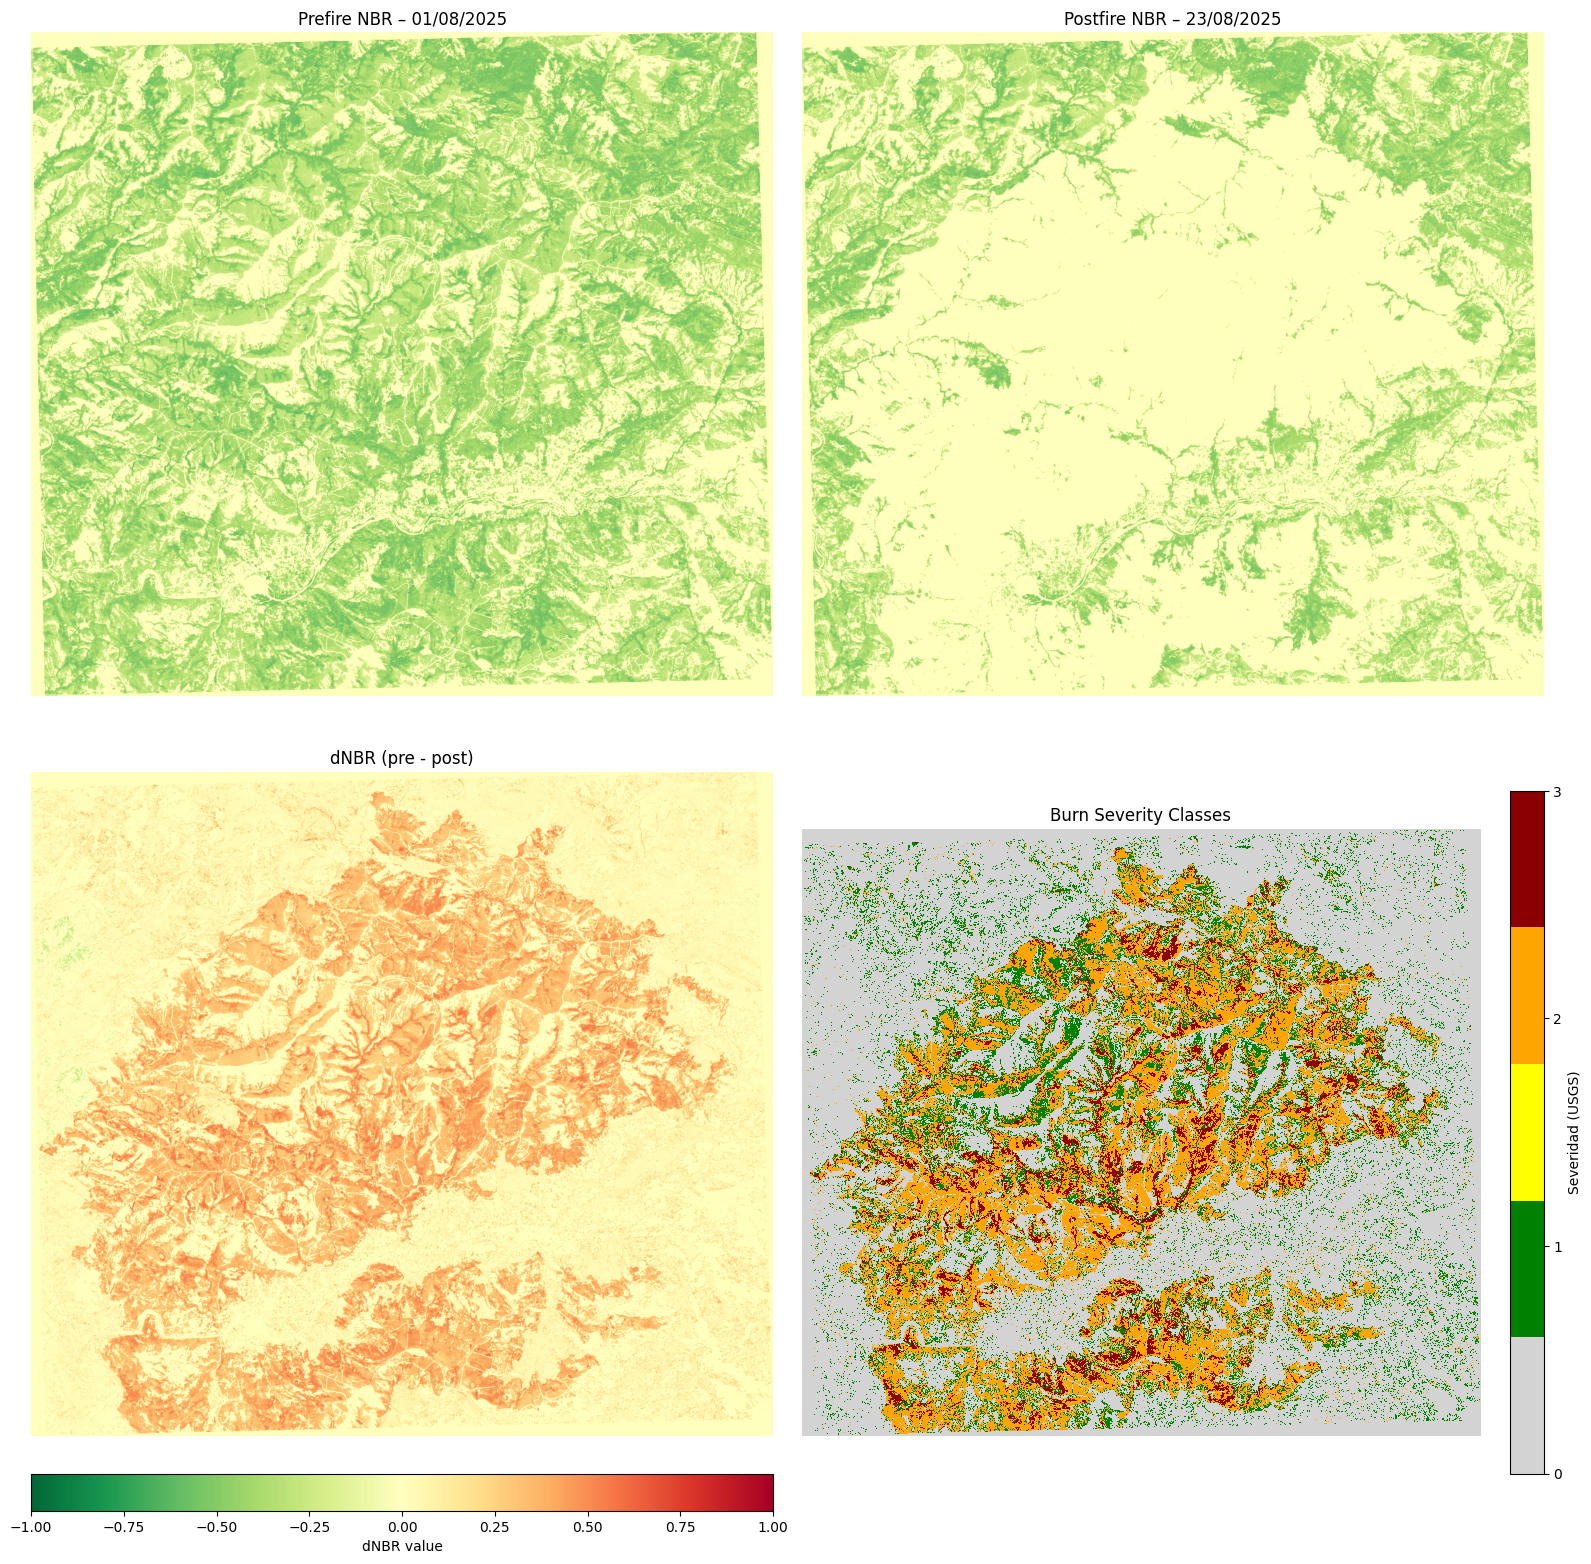

<Figure size 640x480 with 0 Axes>

In [399]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Assuming nbr_pre and nbr_post are already loaded as 2D numpy arrays 
# (from your earlier code, valid pixels only, values in [-1,1] range)

# 1. Compute dNBR
dnbr = nbr_pre - nbr_post

# 2. Create severity classification array
severity = np.full_like(dnbr, 0, dtype=np.uint8)  # 0 = unburned/low/no change

severity[(dnbr < 0.10)] = 0 # Unburned
severity[(dnbr >= 0.1)  & (dnbr < 0.27)] = 1  # Low severity
severity[(dnbr >= 0.27) & (dnbr < 0.44)] = 2  # Moderate-Low severity
severity[(dnbr >= 0.44) & (dnbr < 0.66)] = 3  # Moderate-High severity
severity[(dnbr > 0.66)] = 4 # High severity

# Optional: mask out invalid/negative dNBR if needed (e.g. from clouds/edges)
# severity[dnbr < -0.5] = np.nan  # or handle separately

# 3. Define a nice colormap for severity (gray → yellow → orange → red)
severity_cmap = ListedColormap(['lightgray', 'green', 'yellow', 'orange', 'darkred'])
severity_labels = ['Unburned', 'Low', 'Moderate-Low', 'Moderate-High', 'High']

# 4. Plot: pre-NBR, post-NBR, dNBR, and severity map
fig, axes = plt.subplots(2, 2, figsize=(16, 16))

# Prefire NBR
axes[0,0].imshow(nbr_pre, cmap='RdYlGn', vmin=-1, vmax=1)
axes[0,0].set_title("Prefire NBR – 01/08/2025")
axes[0,0].axis('off')

# Postfire NBR
axes[0,1].imshow(nbr_post, cmap='RdYlGn', vmin=-1, vmax=1)
axes[0,1].set_title("Postfire NBR – 23/08/2025")
axes[0,1].axis('off')

# Continuous dNBR (reversed so positive = red = burn)
im_dnbr = axes[1,0].imshow(dnbr, cmap='RdYlGn_r', vmin=-1, vmax=1)
axes[1,0].set_title("dNBR (pre - post)")
axes[1,0].axis('off')

# Severity classes
im_sev = axes[1,1].imshow(severity, cmap=severity_cmap, vmin=0, vmax=3, interpolation='nearest')
axes[1,1].set_title("Burn Severity Classes")
axes[1,1].axis('off')

# Shared colorbar for dNBR
cbar_dnbr = fig.colorbar(im_dnbr, ax=axes[1,0], orientation='horizontal', fraction=0.05, pad=0.05)
cbar_dnbr.set_label('dNBR value')

# Legend for severity (manual, since discrete)
# Colorbar SOLO para severity
cbar = fig.colorbar(
    im_sev,
    ax=axes[1, 1],
    ticks=range(5),
    fraction=0.046,
    pad=0.04
)
cbar.set_label('Severidad (USGS)')

plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()